# Milestone 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split , StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.preprocessing import LabelEncoder , StandardScaler,PowerTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize


In [161]:
df= pd.read_csv("train_data.csv")
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,disease_diagnosis
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,Healthy
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,Rickets_Osteomalacia
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,Healthy
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,Anemia
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,Healthy


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   gender                   3500 non-null   str    
 2   bmi                      3500 non-null   float64
 3   smoking_status           3500 non-null   str    
 4   alcohol_consumption      2390 non-null   str    
 5   exercise_level           3500 non-null   str    
 6   diet_type                3500 non-null   str    
 7   sun_exposure             3500 non-null   str    
 8   income_level             3500 non-null   str    
 9   latitude_region          3500 non-null   str    
 10  vitamin_a_percent_rda    3500 non-null   float64
 11  vitamin_c_percent_rda    3500 non-null   float64
 12  vitamin_d_percent_rda    3500 non-null   float64
 13  vitamin_e_percent_rda    3500 non-null   float64
 14  vitamin_b12_percent_rda  3500 non-n

In [163]:
# count =df["disease_diagnosis"].value_counts()
# print(count)
# count =df["smoking_status"].value_counts()
# print(count)
# count =df["alcohol_consumption"].value_counts()
# print(count)
# count =df["exercise_level"].value_counts()
# print(count)
count =df["latitude_region"].value_counts()
print(count)


latitude_region
High    1187
Low     1175
Mid     1138
Name: count, dtype: int64


In [ ]:
# X = df.drop(columns=["disease_diagnosis"])
df = pd.get_dummies(df, columns=["gender"])

smoking_map = {'Never':0 , 'Former':1 , 'Current':2}
df["smoking_status"] = df["smoking_status"].map(smoking_map)


           

alc_map = {'Moderate':0 , 'Heavy':1 }
df["alcohol_consumption"] = df["alcohol_consumption"].map(alc_map)  

# exercise_level
# Sedentary    903
# Light        884
# Active       866
# Moderate     847
alc_map = {'Sedentary':0 , 'Light':1 , 'Moderate':2 , 'Active':3 }
df["exercise_level"] = df["exercise_level"].map(alc_map)

 # diet_type
# Vegan          887
# Pescatarian    876
# Omnivore       870
# Vegetarian     867
# diet_map = {'Vegan':0 , 'Pescatarian':1 , 'Omnivore':2 , 'Vegetarian':3 }
# df["diet_type"] = df["diet_type"].map(diet_map)
df = pd.get_dummies(df, columns=["diet_type"])

sun_exposurelll = {'Low':0 , 'Moderate':1 , 'High':2  }
df["sun_exposure"] = df["sun_exposure"].map(sun_exposurelll)

income = {'Low':0 , 'Middle':1 , 'High':2  }
df["income_level"] = df["income_level"].map(income)  

lats = {'Low':0 , 'Mid':1 , 'High':2  }
df["latitude_region"] = df["latitude_region"].map(lats)

        

In [165]:
df.drop(columns=["symptoms_list"], inplace=True)

In [166]:
le = LabelEncoder()
df["disease_diagnosis"] = le.fit_transform(df["disease_diagnosis"])

In [167]:
df.head()

,age,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,...,calcium_percent_rda,iron_percent_rda,symptoms_count,disease_diagnosis,gender_Female,gender_Male,diet_type_Omnivore,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian
0,79,24.8,1,NaN,3,2,2,1,119.1,147.3,...,108.3,97.4,0,1,False,True,False,False,False,True
1,77,39.9,1,0.0,1,0,0,0,85.7,57.5,...,42.6,102.5,1,3,True,False,True,False,False,False
2,24,26.4,1,1.0,2,0,2,2,48.3,152.1,...,136.3,86.4,2,1,False,True,True,False,False,False
3,69,23.1,0,1.0,2,2,0,0,75.8,51.0,...,76.5,60.8,2,0,False,True,False,False,False,True
4,63,29.6,0,NaN,2,1,2,0,93.3,111.5,...,69.4,71.9,0,1,False,True,False,False,False,True


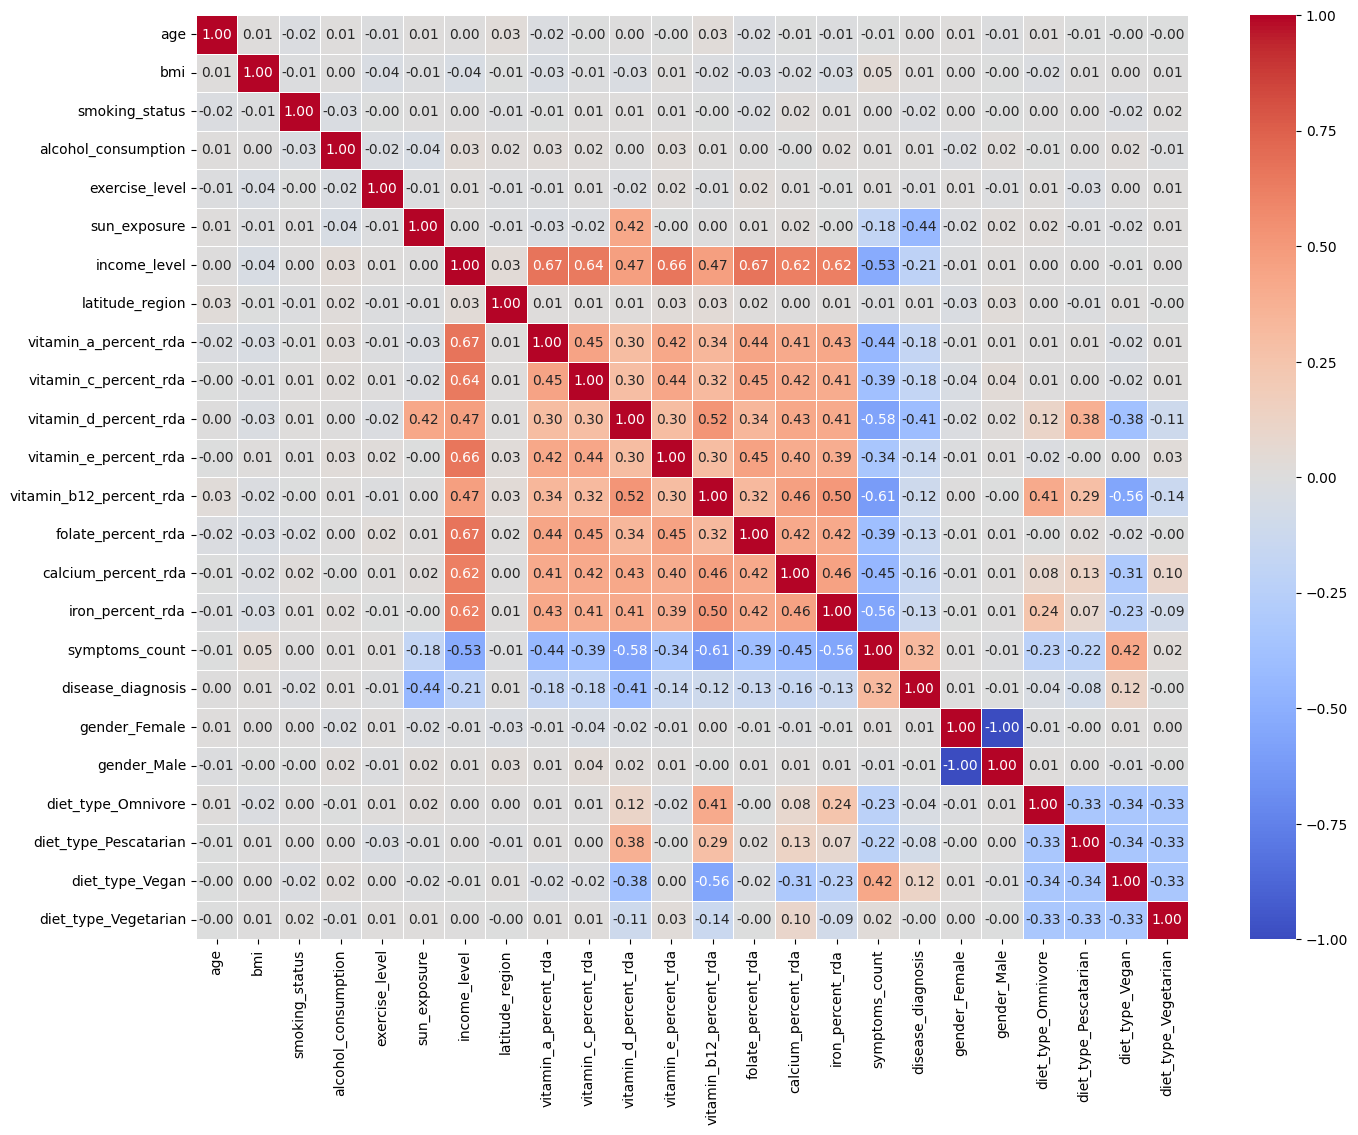

In [168]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.show()

In [169]:

df.drop(columns=["gender_Male","gender_Female","age","bmi","smoking_status","exercise_level","latitude_region"], inplace=True)

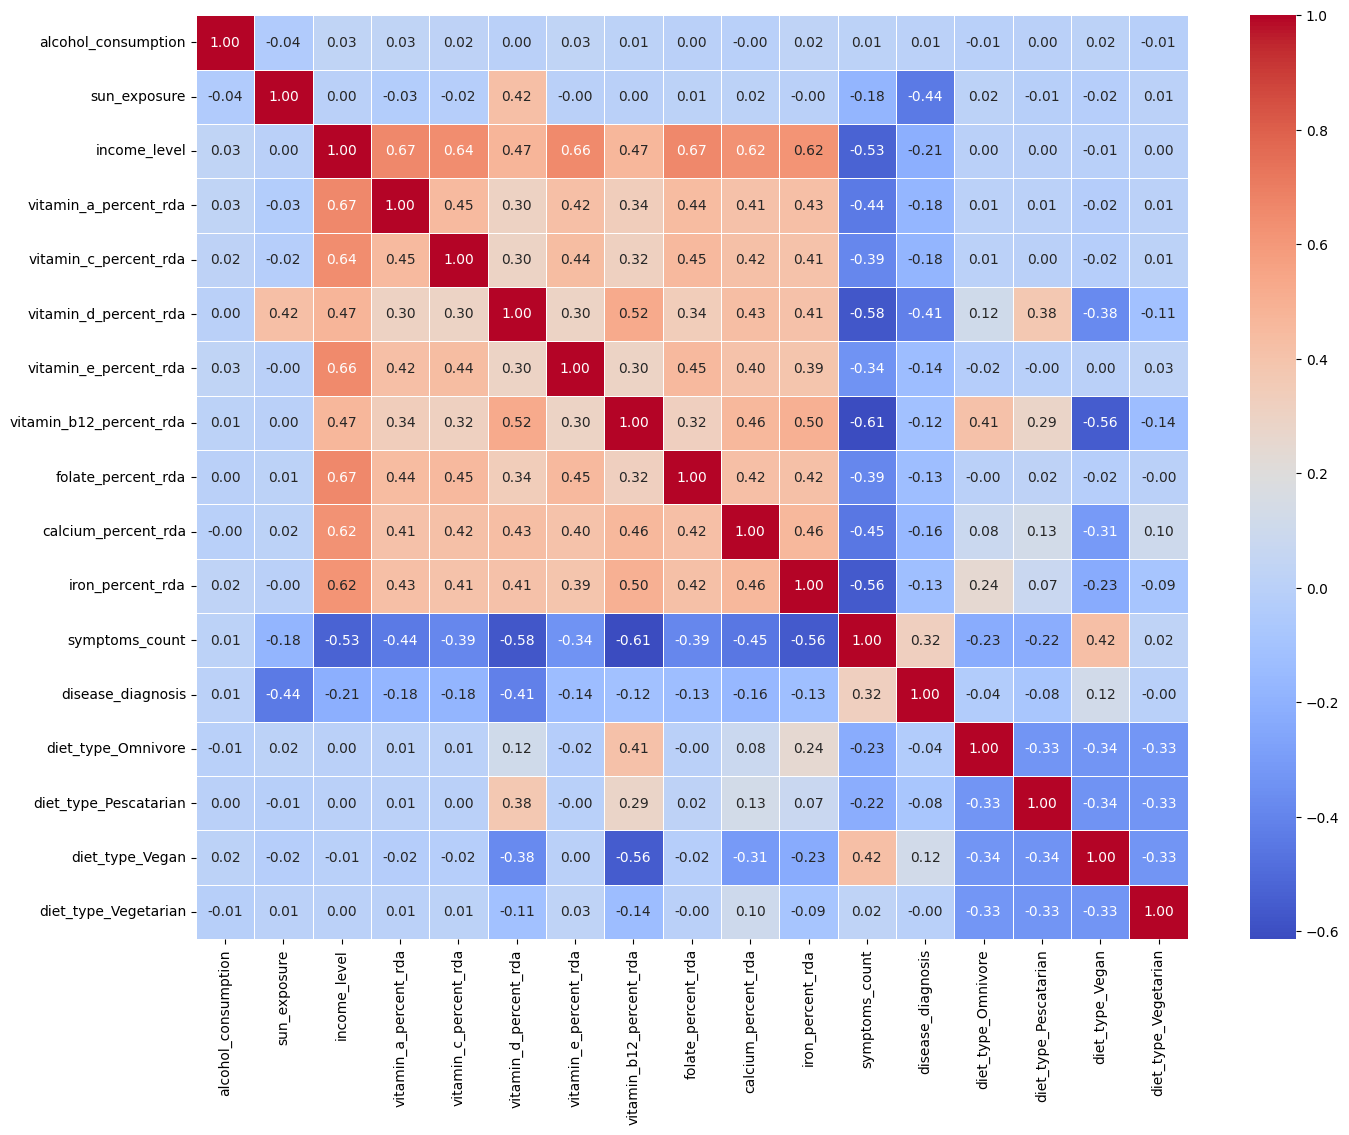

In [170]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.show()

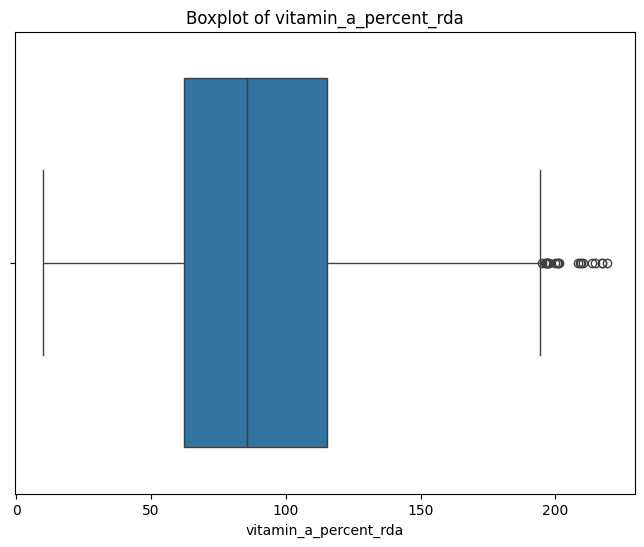

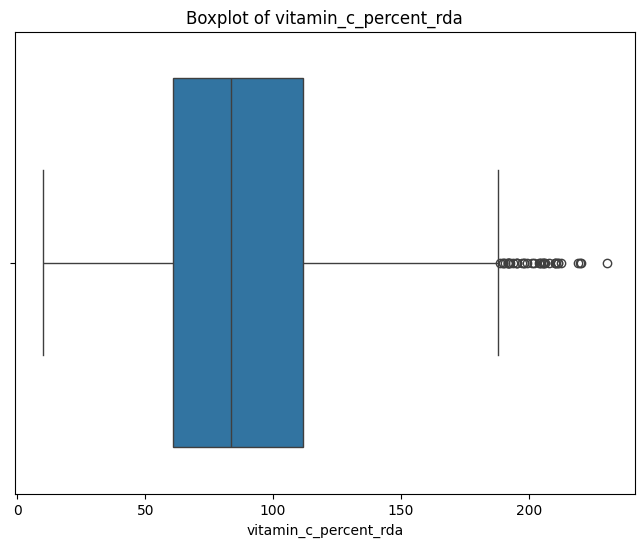

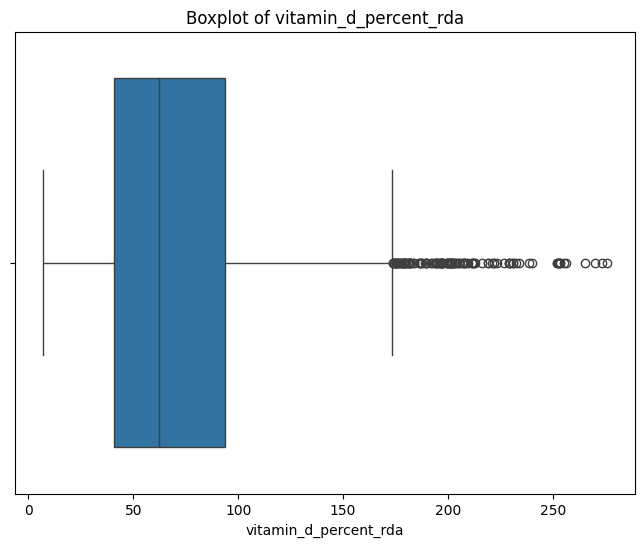

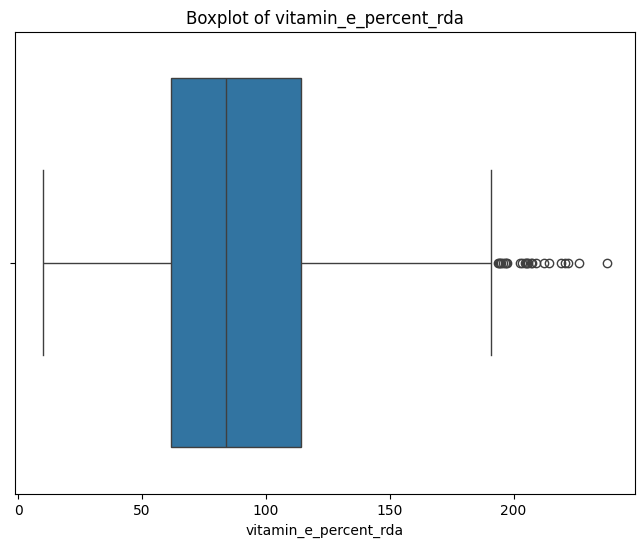

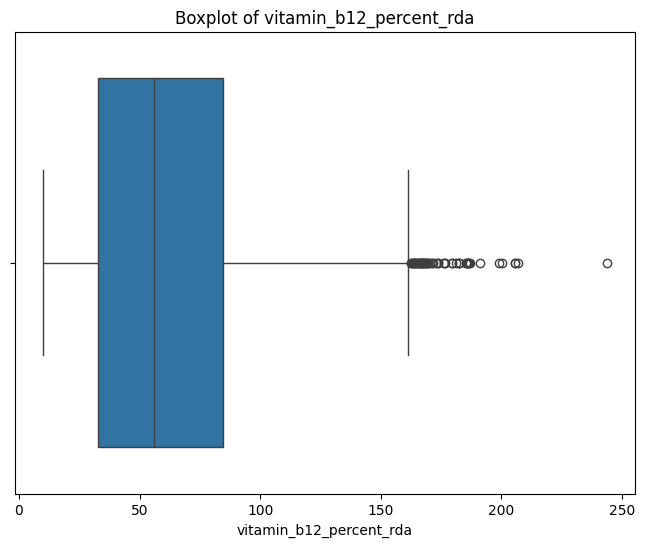

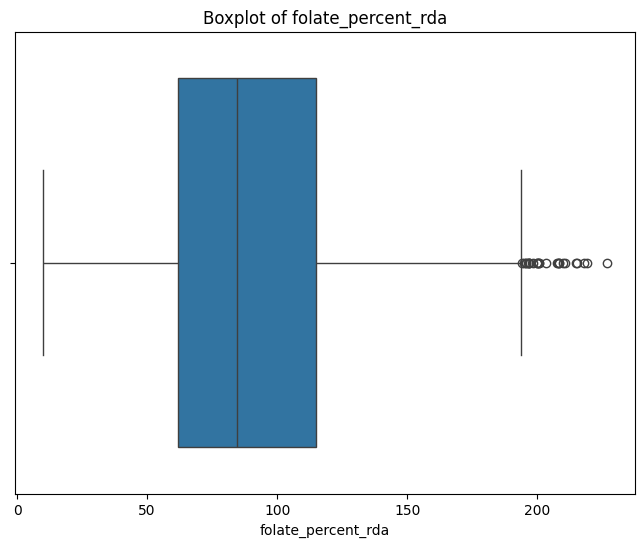

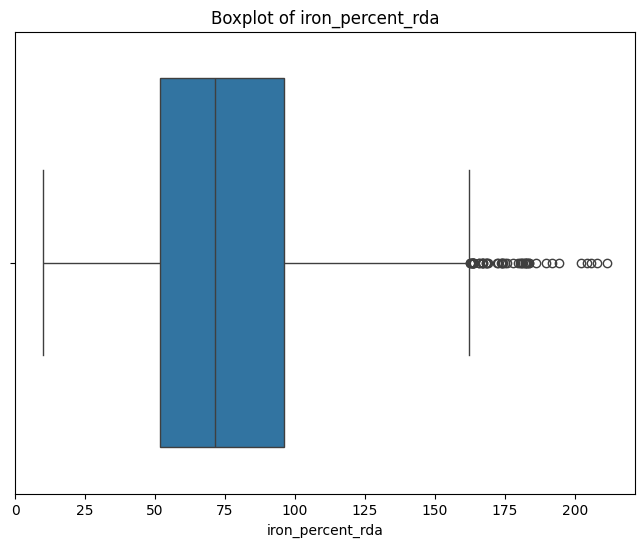

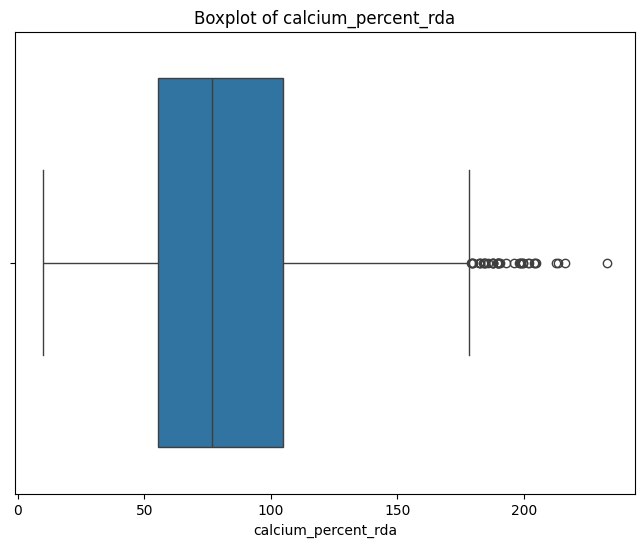

In [171]:
cols= ["vitamin_a_percent_rda","vitamin_c_percent_rda","vitamin_d_percent_rda","vitamin_e_percent_rda","vitamin_b12_percent_rda","folate_percent_rda","iron_percent_rda","calcium_percent_rda"]
for col in cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   alcohol_consumption      2390 non-null   float64
 1   sun_exposure             3500 non-null   int64  
 2   income_level             3500 non-null   int64  
 3   vitamin_a_percent_rda    3500 non-null   float64
 4   vitamin_c_percent_rda    3500 non-null   float64
 5   vitamin_d_percent_rda    3500 non-null   float64
 6   vitamin_e_percent_rda    3500 non-null   float64
 7   vitamin_b12_percent_rda  3500 non-null   float64
 8   folate_percent_rda       3500 non-null   float64
 9   calcium_percent_rda      3500 non-null   float64
 10  iron_percent_rda         3500 non-null   float64
 11  symptoms_count           3500 non-null   int64  
 12  disease_diagnosis        3500 non-null   int32  
 13  diet_type_Omnivore       3500 non-null   bool   
 14  diet_type_Pescatarian    3500 non-n

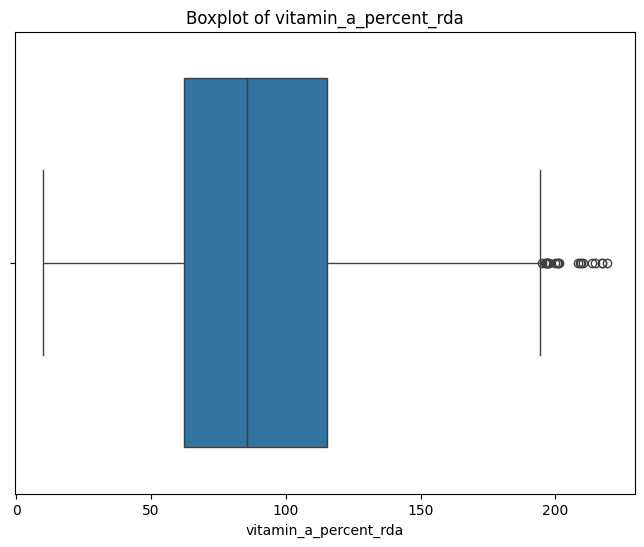

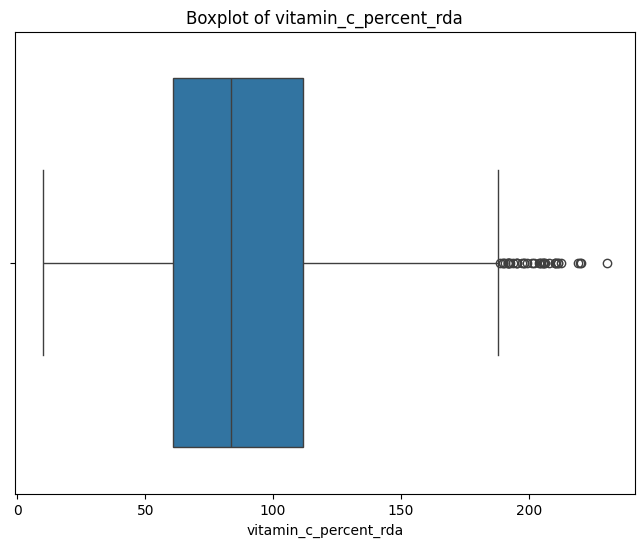

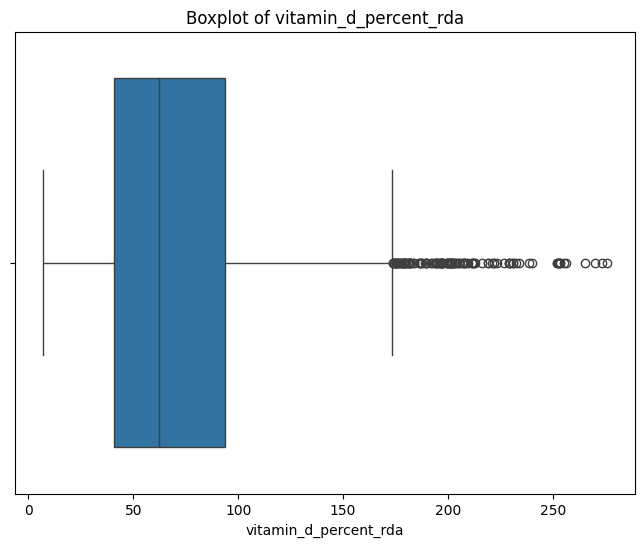

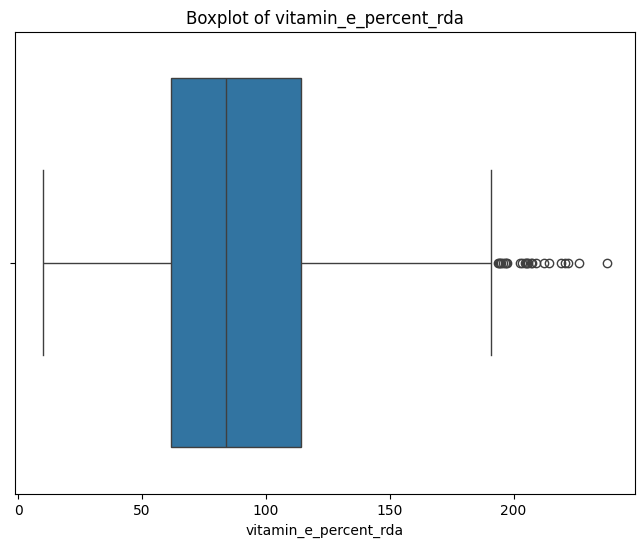

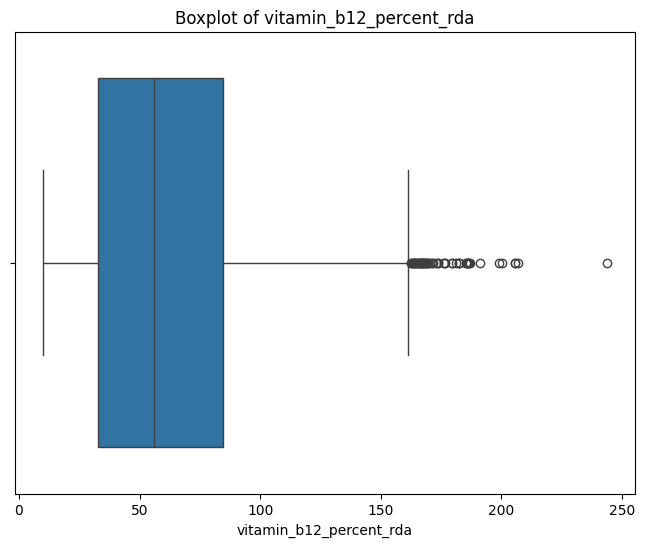

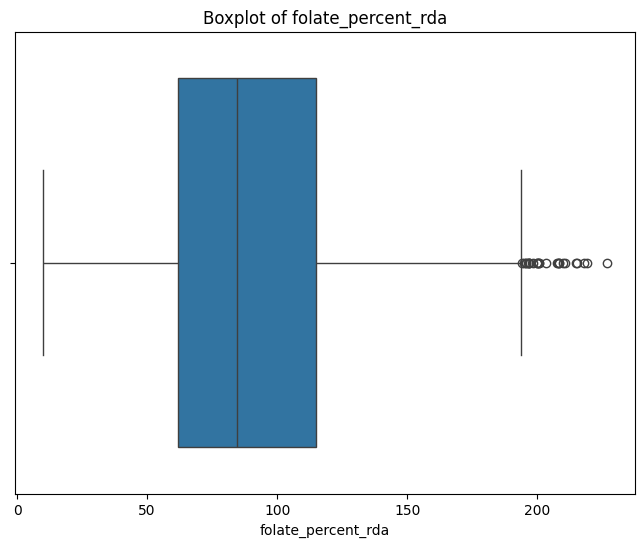

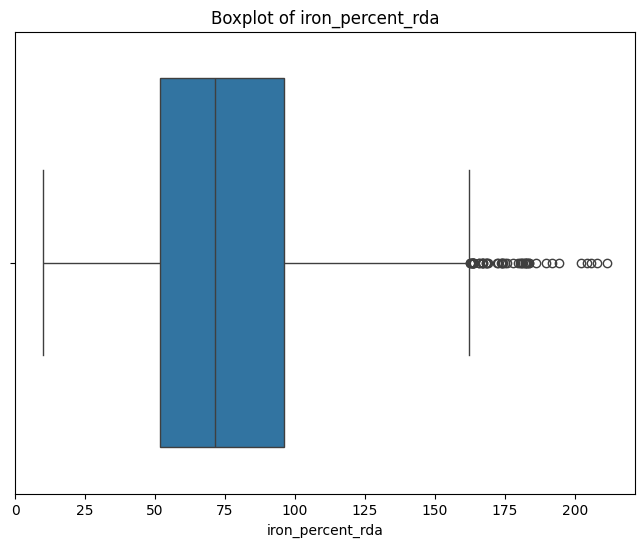

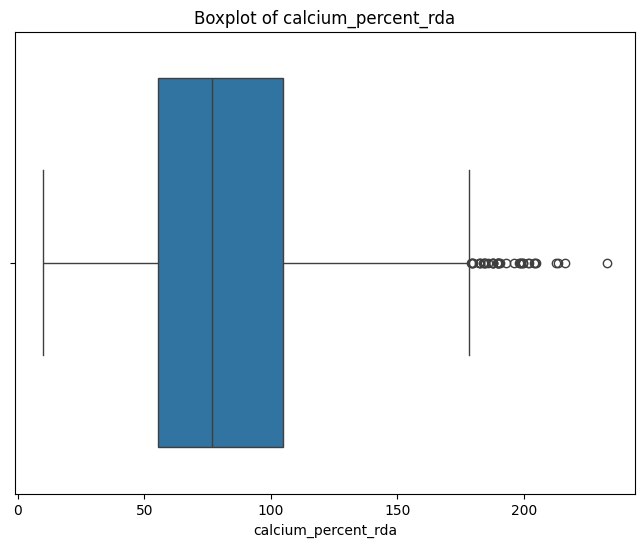

In [174]:
cols= ["vitamin_a_percent_rda","vitamin_c_percent_rda","vitamin_d_percent_rda","vitamin_e_percent_rda","vitamin_b12_percent_rda","folate_percent_rda","iron_percent_rda","calcium_percent_rda"]
for col in cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

array([[<Axes: title={'center': 'alcohol_consumption'}>,
        <Axes: title={'center': 'sun_exposure'}>,
        <Axes: title={'center': 'income_level'}>,
        <Axes: title={'center': 'vitamin_a_percent_rda'}>],
       [<Axes: title={'center': 'vitamin_c_percent_rda'}>,
        <Axes: title={'center': 'vitamin_d_percent_rda'}>,
        <Axes: title={'center': 'vitamin_e_percent_rda'}>,
        <Axes: title={'center': 'vitamin_b12_percent_rda'}>],
       [<Axes: title={'center': 'folate_percent_rda'}>,
        <Axes: title={'center': 'calcium_percent_rda'}>,
        <Axes: title={'center': 'iron_percent_rda'}>,
        <Axes: title={'center': 'symptoms_count'}>],
       [<Axes: title={'center': 'disease_diagnosis'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

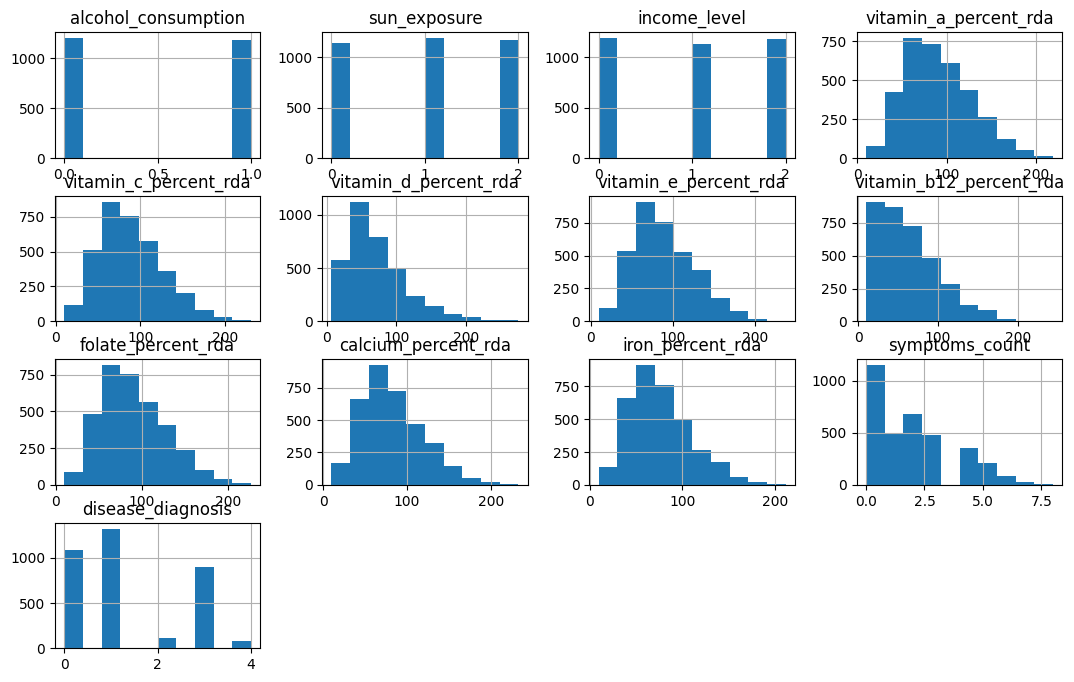

In [175]:
df.hist(figsize=(13,8))

array([[<Axes: title={'center': 'alcohol_consumption'}>,
        <Axes: title={'center': 'sun_exposure'}>,
        <Axes: title={'center': 'income_level'}>,
        <Axes: title={'center': 'vitamin_a_percent_rda'}>],
       [<Axes: title={'center': 'vitamin_c_percent_rda'}>,
        <Axes: title={'center': 'vitamin_d_percent_rda'}>,
        <Axes: title={'center': 'vitamin_e_percent_rda'}>,
        <Axes: title={'center': 'vitamin_b12_percent_rda'}>],
       [<Axes: title={'center': 'folate_percent_rda'}>,
        <Axes: title={'center': 'calcium_percent_rda'}>,
        <Axes: title={'center': 'iron_percent_rda'}>,
        <Axes: title={'center': 'symptoms_count'}>],
       [<Axes: title={'center': 'disease_diagnosis'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

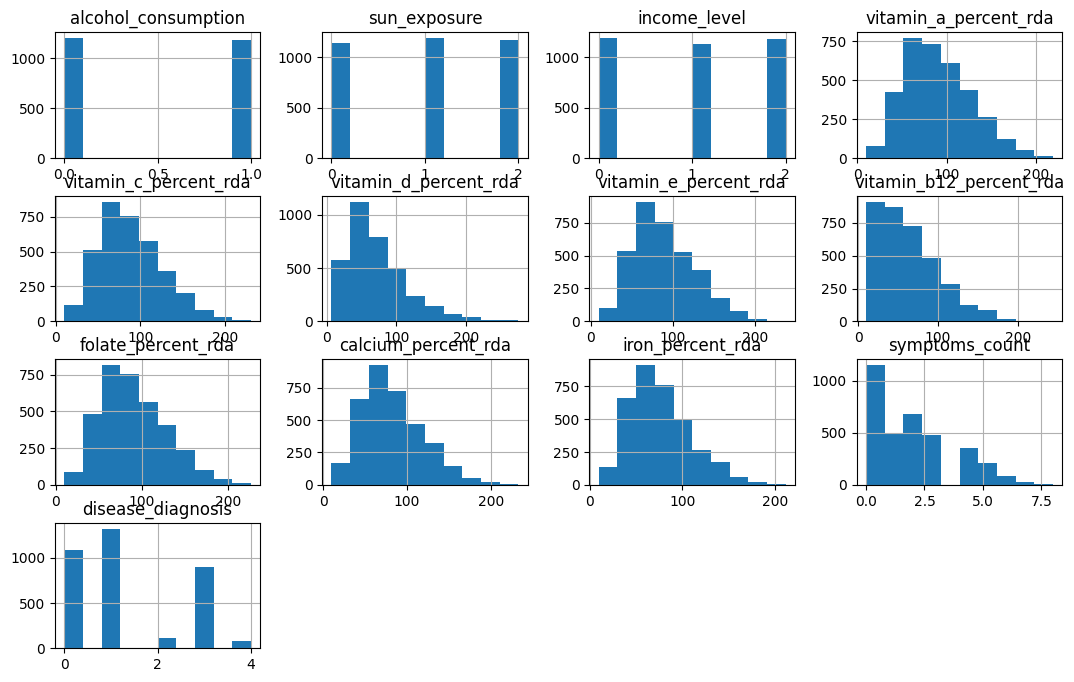

In [177]:
df.hist(figsize=(13,8))

In [178]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   alcohol_consumption      2390 non-null   float64
 1   sun_exposure             3500 non-null   int64  
 2   income_level             3500 non-null   int64  
 3   vitamin_a_percent_rda    3500 non-null   float64
 4   vitamin_c_percent_rda    3500 non-null   float64
 5   vitamin_d_percent_rda    3500 non-null   float64
 6   vitamin_e_percent_rda    3500 non-null   float64
 7   vitamin_b12_percent_rda  3500 non-null   float64
 8   folate_percent_rda       3500 non-null   float64
 9   calcium_percent_rda      3500 non-null   float64
 10  iron_percent_rda         3500 non-null   float64
 11  symptoms_count           3500 non-null   int64  
 12  disease_diagnosis        3500 non-null   int32  
 13  diet_type_Omnivore       3500 non-null   bool   
 14  diet_type_Pescatarian    3500 non-n

In [179]:
df.to_csv("preprocessed_data.csv", index=False)

In [180]:
df = pd.read_csv("preprocessed_data.csv")
X = df.drop(columns=["disease_diagnosis"])
y = df["disease_diagnosis"]
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

In [181]:
for column in cols:
    Q1 = x_train[column].quantile(0.25)
    Q3 = x_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    x_train[column] = x_train[column].clip(lower, upper)
    x_test[column]  = x_test[column].clip(lower, upper)  # use train bounds

In [182]:
train_mode = x_train['alcohol_consumption'].mode()[0]
x_train['alcohol_consumption'] = x_train['alcohol_consumption'].fillna(train_mode)
x_test['alcohol_consumption']  = x_test['alcohol_consumption'].fillna(train_mode)

In [183]:
pt = PowerTransformer(standardize=False)

cols_2 = [
    "vitamin_b12_percent_rda",
    "vitamin_e_percent_rda",
    "vitamin_d_percent_rda",
    "vitamin_c_percent_rda",
    "vitamin_a_percent_rda",
    "folate_percent_rda",
    "iron_percent_rda",
    "calcium_percent_rda",
    "symptoms_count"
]

x_train[cols_2] = pt.fit_transform(x_train[cols_2])

x_test[cols_2] = pt.transform(x_test[cols_2])

In [184]:
scale = StandardScaler()

cols_3 = [
    "vitamin_b12_percent_rda",
    "vitamin_e_percent_rda",
    "vitamin_d_percent_rda",
    "vitamin_c_percent_rda",
    "vitamin_a_percent_rda",
    "folate_percent_rda",
    "iron_percent_rda",
    "calcium_percent_rda"
]

x_train[cols_3] = scale.fit_transform(x_train[cols_3])

x_test[cols_3] = scale.transform(x_test[cols_3])

# decision tree

In [185]:
tree = DecisionTreeClassifier(criterion='entropy',random_state=100, max_depth=5, min_samples_leaf=5)
tree.fit(x_train,y_train)

y_pred = tree.predict(x_test)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:


 [[203  15   0   0   0]
 [  1 263   0   0   0]
 [  0   1  21   0   0]
 [  1   0   0 178   0]
 [  1   7   1   0   8]]

Accuracy: 96.14285714285714

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96       218
           1       0.92      1.00      0.96       264
           2       0.95      0.95      0.95        22
           3       1.00      0.99      1.00       179
           4       1.00      0.47      0.64        17

    accuracy                           0.96       700
   macro avg       0.97      0.87      0.90       700
weighted avg       0.96      0.96      0.96       700



In [186]:
for n in [3,5,6]:
    tree = DecisionTreeClassifier(criterion='entropy',random_state=100, max_depth=n, min_samples_leaf=5)
    tree.fit(x_train,y_train)
    print(f"max_depth={n} -> Accuracy: {accuracy_score(y_test, tree.predict(x_test)) * 100:.2f}%")


max_depth=3 -> Accuracy: 86.43%
max_depth=5 -> Accuracy: 96.14%
max_depth=6 -> Accuracy: 98.14%


In [ ]:

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(tree,X,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.98       0.98714286 0.98857143 0.98857143 0.98428571]
Mean CV accuracy: 0.9857142857142855
Std deviation: 0.0032576440717118128


In [188]:
from sklearn.model_selection import GridSearchCV
parm_tree = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10]
}
grid = GridSearchCV(tree, parm_tree,cv=5)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("accuracy_score:", accuracy_score(y_test, grid.predict(x_test)) * 100)

Best parameters: {'max_depth': 7, 'min_samples_leaf': 1}
accuracy_score: 99.14285714285714


In [189]:
# plt.figure(figsize=(20,8))
# plot_tree(tree, filled=True, feature_names=X.columns, class_names=y.classes_, rounded=True)

# XGB model

In [190]:
for n in [50,100,200]:
    xgb = XGBClassifier(random_state=42, n_estimators=n,learning_rate=0.1)
    xgb.fit(x_train, y_train)
    print(f"n_estimators={n} -> Accuracy: {accuracy_score(y_test, xgb.predict(x_test)) * 100:.2f}%")

n_estimators=50 -> Accuracy: 99.14%
n_estimators=100 -> Accuracy: 99.14%
n_estimators=200 -> Accuracy: 99.14%


In [191]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(xgb,X,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.99857143 0.99571429 0.99142857 0.99428571 0.99285714]
Mean CV accuracy: 0.9945714285714284
Std deviation: 0.0024578072191550194


In [192]:
from sklearn.model_selection import GridSearchCV
parm = {
    'n_estimators': [50, 100, 200,300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7,10]
}
grid = GridSearchCV(xgb, parm,cv=5)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("accuracy_score:", accuracy_score(y_test, grid.predict(x_test)) * 100)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
accuracy_score: 99.14285714285714



✅ Feature Importances ✅
                    Feature  Importance
11           symptoms_count    0.415588
5     vitamin_d_percent_rda    0.162120
7   vitamin_b12_percent_rda    0.129201
1              sun_exposure    0.071462
10         iron_percent_rda    0.055585
3     vitamin_a_percent_rda    0.052979
4     vitamin_c_percent_rda    0.050051
8        folate_percent_rda    0.047373
13    diet_type_Pescatarian    0.007209
0       alcohol_consumption    0.003490
6     vitamin_e_percent_rda    0.002491
9       calcium_percent_rda    0.001114
12       diet_type_Omnivore    0.000769
14          diet_type_Vegan    0.000451
2              income_level    0.000114
15     diet_type_Vegetarian    0.000000


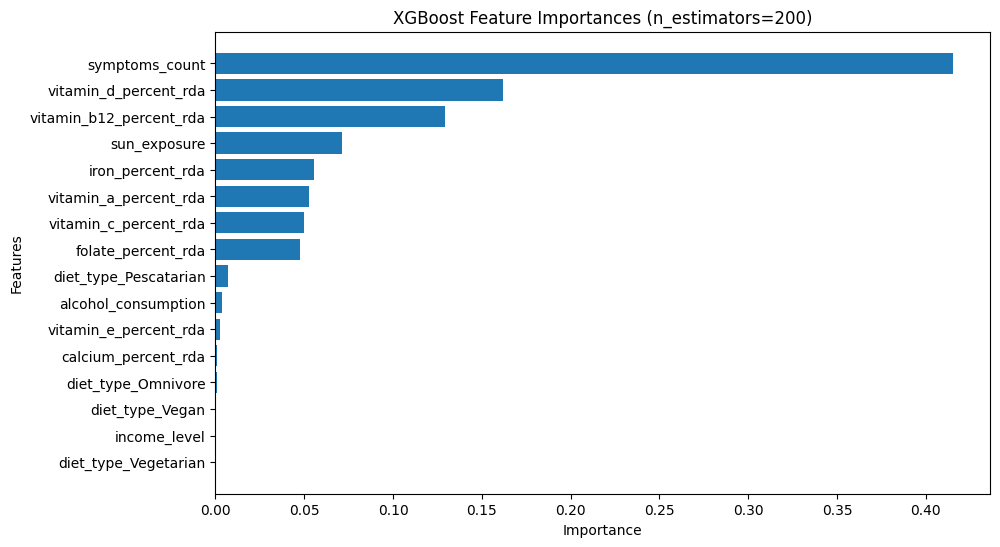

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n✅ Feature Importances ✅")
print(importance_df)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title(f"XGBoost Feature Importances (n_estimators={n})")

plt.gca().invert_yaxis()

plt.show()

✅ XGBoost ROC-AUC: 0.9999337860610525


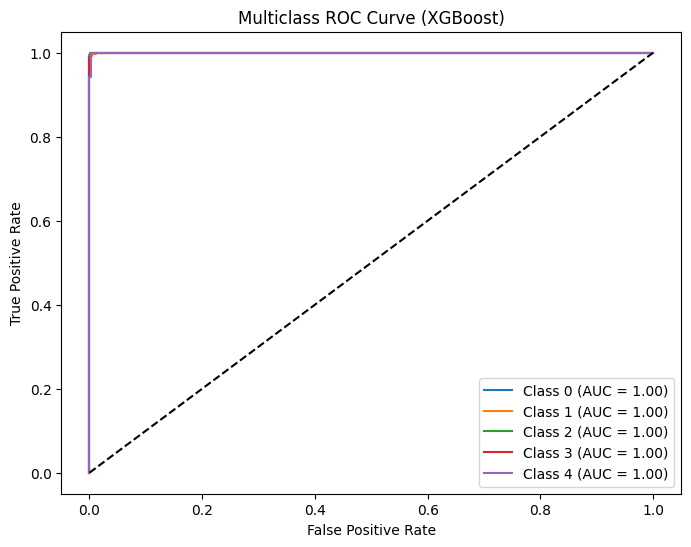

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    eval_metric='mlogloss'
)

xgb.fit(x_train, y_train)


y_proba_xgb = xgb.predict_proba(x_test)

# ROC-AUC Score
print("X GBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb,multi_class='ovr',average='macro'))

n_classes = len(np.unique(y_test))

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)


plt.figure(figsize=(8,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve( y_test_bin[:, i],y_proba_xgb[:, i] )

    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr,label=f"Class {i} (AUC = {roc_auc:.2f})" )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve (XGBoost)")

plt.legend()

plt.savefig( "roc_curve_xgboost.png",dpi=300,bbox_inches="tight")

plt.show()

In [195]:
for k in [3,5,7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    print(f"k={k} -> Accuracy: {accuracy_score(y_test, knn.predict(x_test)) * 100:.2f}%")

k=3 -> Accuracy: 80.57%
k=5 -> Accuracy: 82.43%
k=7 -> Accuracy: 82.57%


In [196]:
parm = {
    'n_neighbors': [3, 5, 7],
}
grid = GridSearchCV(knn, parm,cv=5)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("accuracy_score:", accuracy_score(y_test, grid.predict(x_test)) * 100)

Best parameters: {'n_neighbors': 7}
accuracy_score: 82.57142857142857


In [ ]:
rf = RandomForestClassifier(random_state=42,class_weight='balanced')


parm = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}


grid = GridSearchCV(
    rf,
    parm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best parameters:", grid.best_params_)

y_pred = grid.predict(x_test)

print("Accuracy Score:",
      accuracy_score(y_test, y_pred) * 100)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

✅ Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
✅ Accuracy Score: 99.28571428571429

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       218
           1       0.99      1.00      0.99       264
           2       1.00      1.00      1.00        22
           3       1.00      0.99      1.00       179
           4       1.00      1.00      1.00        17

    accuracy                           0.99       700
   macro avg       1.00      1.00      1.00       700
weighted avg       0.99      0.99      0.99       700



In [ ]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_scores = cross_val_score(grid.best_estimator_,X,y,cv=cv,scoring='accuracy',n_jobs=-1)

print("Cross-validation accuracies :", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅ Cross-validation accuracies ✅: [0.99571429 0.99571429 0.99428571 0.99285714 0.99571429]
✅ Mean CV accuracy: 0.9948571428571429
✅ Std deviation: 0.0011428571428571065



✅ Feature Importances ✅
                    Feature  Importance
4     vitamin_c_percent_rda    0.257720
3     vitamin_a_percent_rda    0.218136
5     vitamin_d_percent_rda    0.178679
11           symptoms_count    0.105214
7   vitamin_b12_percent_rda    0.072269
1              sun_exposure    0.056565
10         iron_percent_rda    0.029101
8        folate_percent_rda    0.027898
9       calcium_percent_rda    0.013265
2              income_level    0.012121
14          diet_type_Vegan    0.011848
6     vitamin_e_percent_rda    0.010737
0       alcohol_consumption    0.002074
13    diet_type_Pescatarian    0.001888
12       diet_type_Omnivore    0.001500
15     diet_type_Vegetarian    0.000986


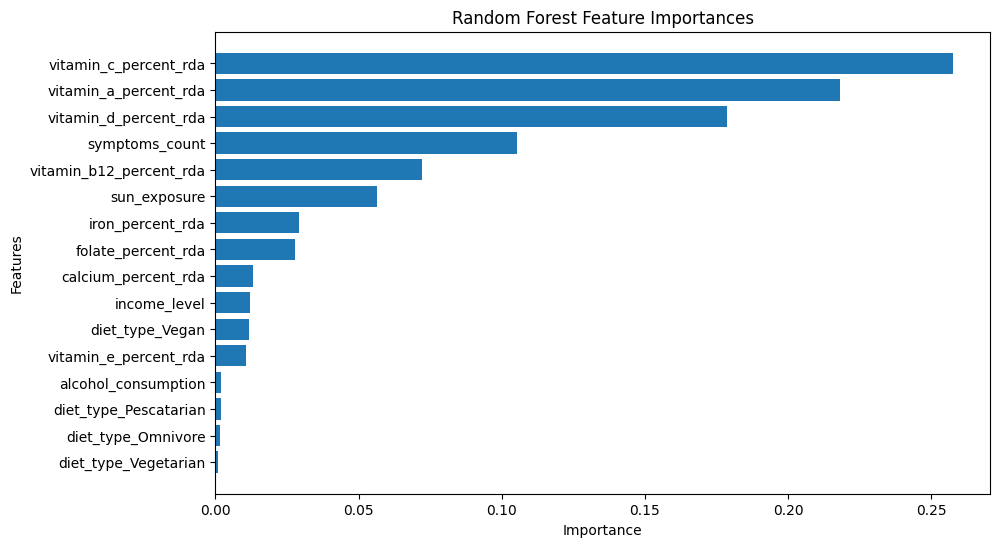

In [ ]:
best_rf = grid.best_estimator_

importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importances")
print(feature_importance_df)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importances")

plt.gca().invert_yaxis()

plt.show()

✅ Random Forest ROC-AUC: 0.9998566045125201


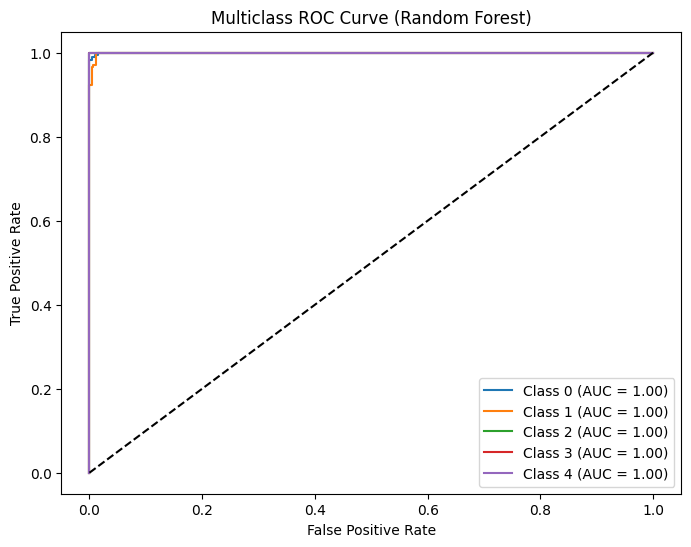

In [ ]:
y_proba_rf = best_rf.predict_proba(x_test)


print("Random Forest ROC-AUC:",roc_auc_score(y_test,y_proba_rf,multi_class='ovr',average='macro'))

n_classes = len(np.unique(y_test))

y_test_bin = label_binarize(y_test,classes=np.arange(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i],y_proba_rf[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr,tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve (Random Forest)")

plt.legend()

plt.savefig("roc_curve_random_forest.png",dpi=300,bbox_inches="tight")

plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)


voting_model = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'   
)

voting_model.fit(x_train, y_train)

y_pred = voting_model.predict(x_test)

acc = accuracy_score(y_test, y_pred)

print("Voting Classifier Accuracy:",
      acc * 100)


✅ Voting Classifier Accuracy: 99.71428571428571


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(voting_model,X,y,cv=cv,scoring='accuracy',n_jobs=-1)

print("Cross-validation accuracies :",cv_scores)

print("Mean CV accuracy:",np.mean(cv_scores))

print("Std deviation:",np.std(cv_scores))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

✅ Cross-validation accuracies ✅: [1.         0.99714286 0.99285714 0.99428571 0.99428571]
✅ Mean CV accuracy: 0.9957142857142858
✅ Std deviation: 0.0025555062599997404

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       218
           1       1.00      1.00      1.00       264
           2       1.00      1.00      1.00        22
           3       0.99      1.00      1.00       179
           4       1.00      0.94      0.97        17

    accuracy                           1.00       700
   macro avg       1.00      0.99      0.99       700
weighted avg       1.00      1.00      1.00       700



In [203]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [ ]:
import pickle


with open("random_forest.pkl", "wb") as f:
    pickle.dump(best_rf, f)

with open("xgboost.pkl", "wb") as f:
    pickle.dump(xgb, f)

with open("voting_model.pkl", "wb") as f:
    pickle.dump(voting_model, f)

print("Models saved successfully")

✅ Models saved successfully


In [ ]:

with open("voting_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully")

y_pred = loaded_model.predict(x_test)

acc = accuracy_score(y_test, y_pred)

print("Loaded Voting Model Accuracy:", acc * 100)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

✅ Model loaded successfully
✅ Loaded Voting Model Accuracy: 99.71428571428571

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       218
           1       1.00      1.00      1.00       264
           2       1.00      1.00      1.00        22
           3       0.99      1.00      1.00       179
           4       1.00      0.94      0.97        17

    accuracy                           1.00       700
   macro avg       1.00      0.99      0.99       700
weighted avg       1.00      1.00      1.00       700



In [ ]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_scores = cross_val_score(loaded_model,X,y,cv=cv,scoring='accuracy',n_jobs=-1)

print("CV scores:", cv_scores)
print("Mean CV:", np.mean(cv_scores))
print("Std CV:", np.std(cv_scores))



✅ CV scores: [1.         0.99714286 0.99285714 0.99428571 0.99428571]
Mean CV: 0.9957142857142858
Std CV: 0.0025555062599997404


✅ Voting Classifier ROC-AUC: 0.9999533869960293
✅ Voting Classifier AP Score: 0.9987419052851433


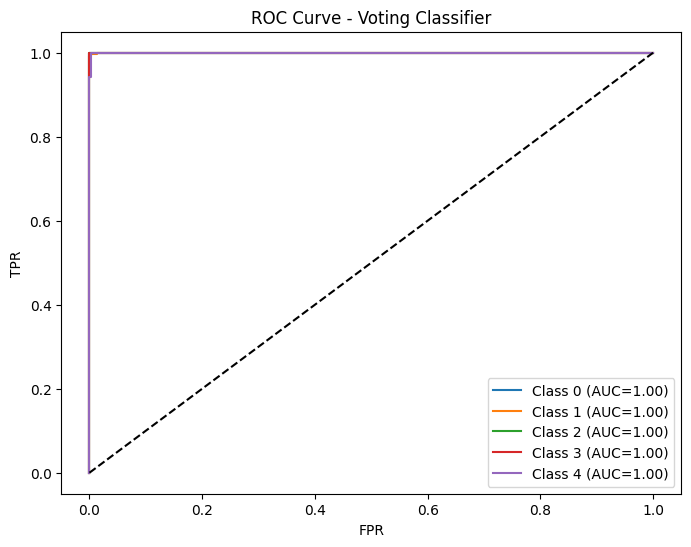

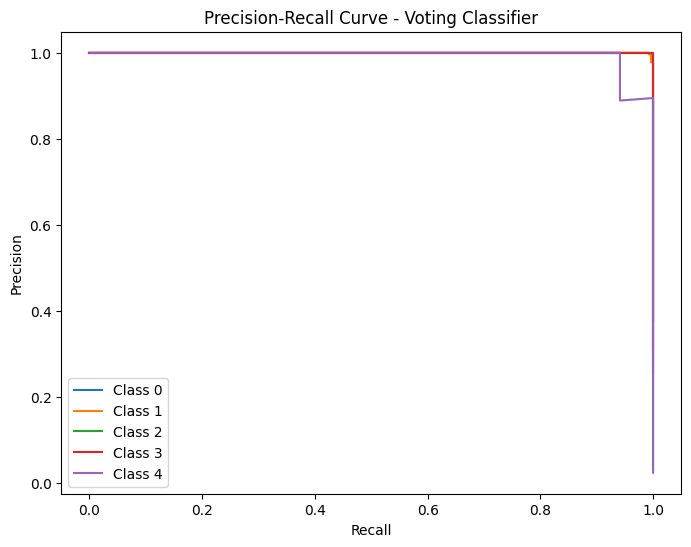

In [ ]:
y_proba = loaded_model.predict_proba(x_test)

auc_score = roc_auc_score(y_test,y_proba,multi_class='ovr',average='macro')

print("Voting Classifier ROC-AUC:", auc_score)
ap_score = average_precision_score(y_test_bin,y_proba,average='macro')

print("Voting Classifier AP Score:", ap_score)

n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Voting Classifier")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_proba[:, i]
    )

    plt.plot(recall, precision, label=f"Class {i}")

plt.title("Precision-Recall Curve - Voting Classifier")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [213]:
with open("xgboost.pkl", "rb") as f:
    xgb = pickle.load(f)

xgb.fit(x_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'



✅ Voting Classifier Feature Importance (Averaged)
                    Feature  Importance
11           symptoms_count    0.260401
5     vitamin_d_percent_rda    0.170400
4     vitamin_c_percent_rda    0.153886
3     vitamin_a_percent_rda    0.135557
7   vitamin_b12_percent_rda    0.100735
1              sun_exposure    0.064013
10         iron_percent_rda    0.042343
8        folate_percent_rda    0.037636
9       calcium_percent_rda    0.007189
6     vitamin_e_percent_rda    0.006614
14          diet_type_Vegan    0.006150
2              income_level    0.006117
13    diet_type_Pescatarian    0.004549
0       alcohol_consumption    0.002782
12       diet_type_Omnivore    0.001135
15     diet_type_Vegetarian    0.000493


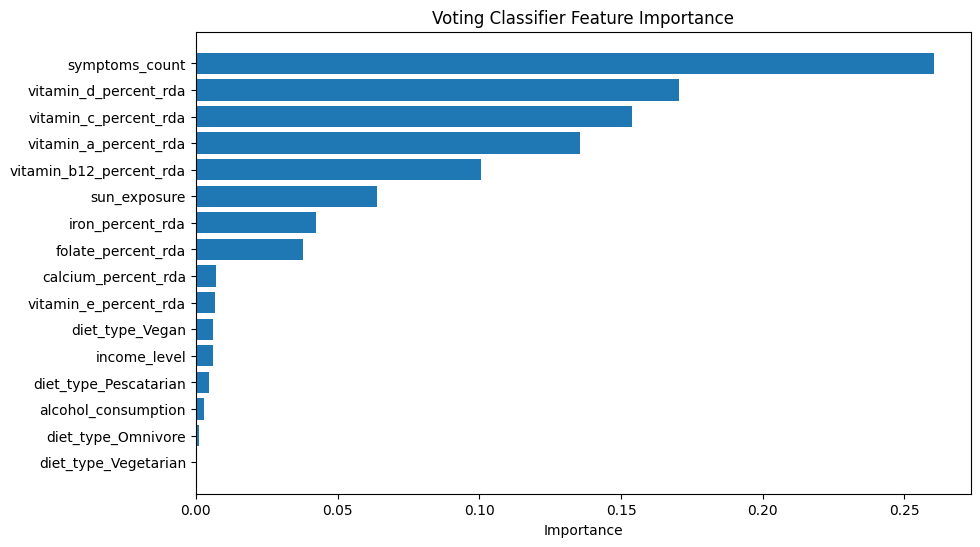

In [ ]:
rf_importance = best_rf.feature_importances_
xgb_importance = xgb.feature_importances_

avg_importance = (rf_importance + xgb_importance) / 2

feature_importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': avg_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nVoting Classifier Feature Importance (Averaged)")
print(feature_importance_df)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.gca().invert_yaxis()
plt.title("Voting Classifier Feature Importance")
plt.xlabel("Importance")

plt.show()